# Change Detection Task (CDT) Analysis

This notebook analyzes CDT data from both datapruebas and neuropruebas sources.

## Usage
There are two ways to use this notebook:

1. **Load existing analysis** (fast): Use `get_latest_cdt_analysis()` to load pre-computed results
2. **Run fresh analysis** (slow): Execute the full pipeline with `load_cdt_analysis()`

To run the analysis from command line:
```bash
python -m src.loader.cdt_analysis_loader
```

## Metrics computed:
- **K_4, K_6**: Cowan's K (working memory capacity for 4 and 6 items)
- **accuracy**: Proportion of correct responses
- **media_rt, mediana_rt**: Mean and median response times
- **trials_no_contestados**: Number of unanswered trials


In [1]:
import os
import sys

# Add project root to path
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.analysis import ChangeDetectionTask
from src.loader import load_cdt_experiment, load_cdt_analysis, get_latest_cdt_analysis
from src import config

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline


## 1. Load Data

**Option A**: Load latest pre-computed analysis (fast)


In [2]:
# Load latest pre-computed analysis
result = get_latest_cdt_analysis()

if result is not None:
    df_cdt_all, run_config = result
    print(f"Loaded analysis from: {run_config.get('timestamp', 'unknown')}")
    print(f"Total subjects: {len(df_cdt_all)}")
    
    # Split by origin for compatibility with rest of notebook
    df_cdt_datapruebas = df_cdt_all[df_cdt_all["origin"] == "datapruebas"].copy()
    df_cdt_neuropruebas = df_cdt_all[df_cdt_all["origin"] == "neuropruebas"].copy()
    print(f"  - Datapruebas: {len(df_cdt_datapruebas)}")
    print(f"  - Neuropruebas: {len(df_cdt_neuropruebas)}")
else:
    print("No pre-computed analysis found. Run Option B below or execute:")
    print("  python -m src.loader.cdt_analysis_loader")


run_dirs: [PosixPath('/home/gus/Documents/REPOS/datapruebas_analysis/data/cdt_analysis/2025-12-19_17-39-11'), PosixPath('/home/gus/Documents/REPOS/datapruebas_analysis/data/cdt_analysis/2025-12-19_17-10-47')]
Loaded analysis from: 2025-12-19_17-39-11
Total subjects: 256
  - Datapruebas: 49
  - Neuropruebas: 207


**Option B**: Run fresh analysis (slow, use if no pre-computed data exists)


In [3]:
# SKIP THIS CELL if you already loaded data in Option A
# Uncomment and run only if you need fresh analysis

# df_cdt_all, save_path = load_cdt_analysis(save_results=True)
# df_cdt_datapruebas = df_cdt_all[df_cdt_all["origin"] == "datapruebas"].copy()
# df_cdt_neuropruebas = df_cdt_all[df_cdt_all["origin"] == "neuropruebas"].copy()
# print(f"Analysis complete. Saved to: {save_path}")


## 2. Data Overview


In [4]:
# Quick view of the data
print(f"Total subjects: {len(df_cdt_all)}")
print(f"Columns: {list(df_cdt_all.columns)}")
df_cdt_all.head(10)


Total subjects: 256
Columns: ['subject_id', 'media_rt', 'mediana_rt', 'trials_no_contestados', 'accuracy', 'accuracy_4', 'accuracy_6', 'K_4', 'K_6', 'n_trials_4', 'n_trials_6', 'view_dist_cm', 'origin']


,subject_id,media_rt,mediana_rt,trials_no_contestados,accuracy,accuracy_4,accuracy_6,K_4,K_6,n_trials_4,n_trials_6,view_dist_cm,origin
0,3f45b93b-b0e2-427d-a081-40a19722db2f,1350.73,1130.10,1,0.89,0.92,0.87,3.32,4.40,60,60,48.56,datapruebas
1,48122ee0-cb8e-4a65-8c6a-3e41353c39e8,1357.50,1269.20,0,0.71,0.80,0.62,2.40,1.40,60,60,43.62,datapruebas
2,0755a318-a863-4a7f-8a44-d5e4fa09fb46,916.30,851.00,0,0.75,0.83,0.67,2.67,2.00,60,60,40.02,datapruebas
3,d82cfda0-f10e-4619-bff0-d78b387387f5,1133.70,1111.50,0,0.76,0.78,0.73,2.27,2.80,60,60,54.95,datapruebas
4,d4f029b7-a1cd-4868-bf6d-0b9ab4bfe419,1178.63,1075.65,0,0.58,0.55,0.62,0.40,1.40,60,60,47.25,datapruebas
5,4ba9507b-7579-4553-bc1c-d65cdb304613,819.65,750.95,0,0.81,0.88,0.73,3.07,2.80,60,60,40.49,datapruebas
6,3d00f43e-3c2f-44bc-91a4-618f785fb778,750.71,708.25,0,0.78,0.87,0.68,2.93,2.20,60,60,56.50,datapruebas
7,075b58cb-69b4-42c1-b1cd-95325bc36df5,872.58,742.40,0,0.86,0.92,0.80,3.33,3.60,60,60,68.01,datapruebas
8,b658934b-1bbc-4897-a989-1827a61cfb03,1328.58,1137.70,1,0.68,0.75,0.61,2.00,1.32,60,60,51.64,datapruebas
9,d6dbecb5-0082-47d8-b681-e433b29f64eb,1007.37,904.50,0,0.82,0.93,0.72,3.47,2.60,60,60,35.38,datapruebas


## 3. Descriptive Statistics


In [5]:
# Summary statistics by origin
metrics_cols = ["K_4", "K_6", "accuracy", "accuracy_4", "accuracy_6", "media_rt", "mediana_rt", "trials_no_contestados"]
available_cols = [c for c in metrics_cols if c in df_cdt_all.columns]
df_cdt_all.groupby("origin")[available_cols].describe().T


origin                       datapruebas  neuropruebas
K_4                   count    49.000000    207.000000
                      mean      2.695918      2.789034
                      std       0.806845      0.664852
                      min       0.340000      0.130000
                      25%       2.400000      2.400000
...                                  ...           ...
trials_no_contestados min       0.000000      0.000000
                      25%       0.000000      0.000000
                      50%       0.000000      0.000000
                      75%       0.000000      0.000000
                      max      76.000000     10.000000

[64 rows x 2 columns]

In [6]:
# Cowan's K descriptive stats
print("Cowan's K Statistics by Origin:")
print("=" * 40)
print("\nDatapruebas:")
print(f"K_4: mean={df_cdt_datapruebas['K_4'].mean():.2f}, SD={df_cdt_datapruebas['K_4'].std():.2f}")
print(f"K_6: mean={df_cdt_datapruebas['K_6'].mean():.2f}, SD={df_cdt_datapruebas['K_6'].std():.2f}")
print("\nNeuropruebas:")
print(f"K_4: mean={df_cdt_neuropruebas['K_4'].mean():.2f}, SD={df_cdt_neuropruebas['K_4'].std():.2f}")
print(f"K_6: mean={df_cdt_neuropruebas['K_6'].mean():.2f}, SD={df_cdt_neuropruebas['K_6'].std():.2f}")


Cowan's K Statistics by Origin:

Datapruebas:
K_4: mean=2.70, SD=0.81
K_6: mean=2.35, SD=1.09

Neuropruebas:
K_4: mean=2.79, SD=0.66
K_6: mean=2.42, SD=1.06


## 4. Cowan's K Distribution


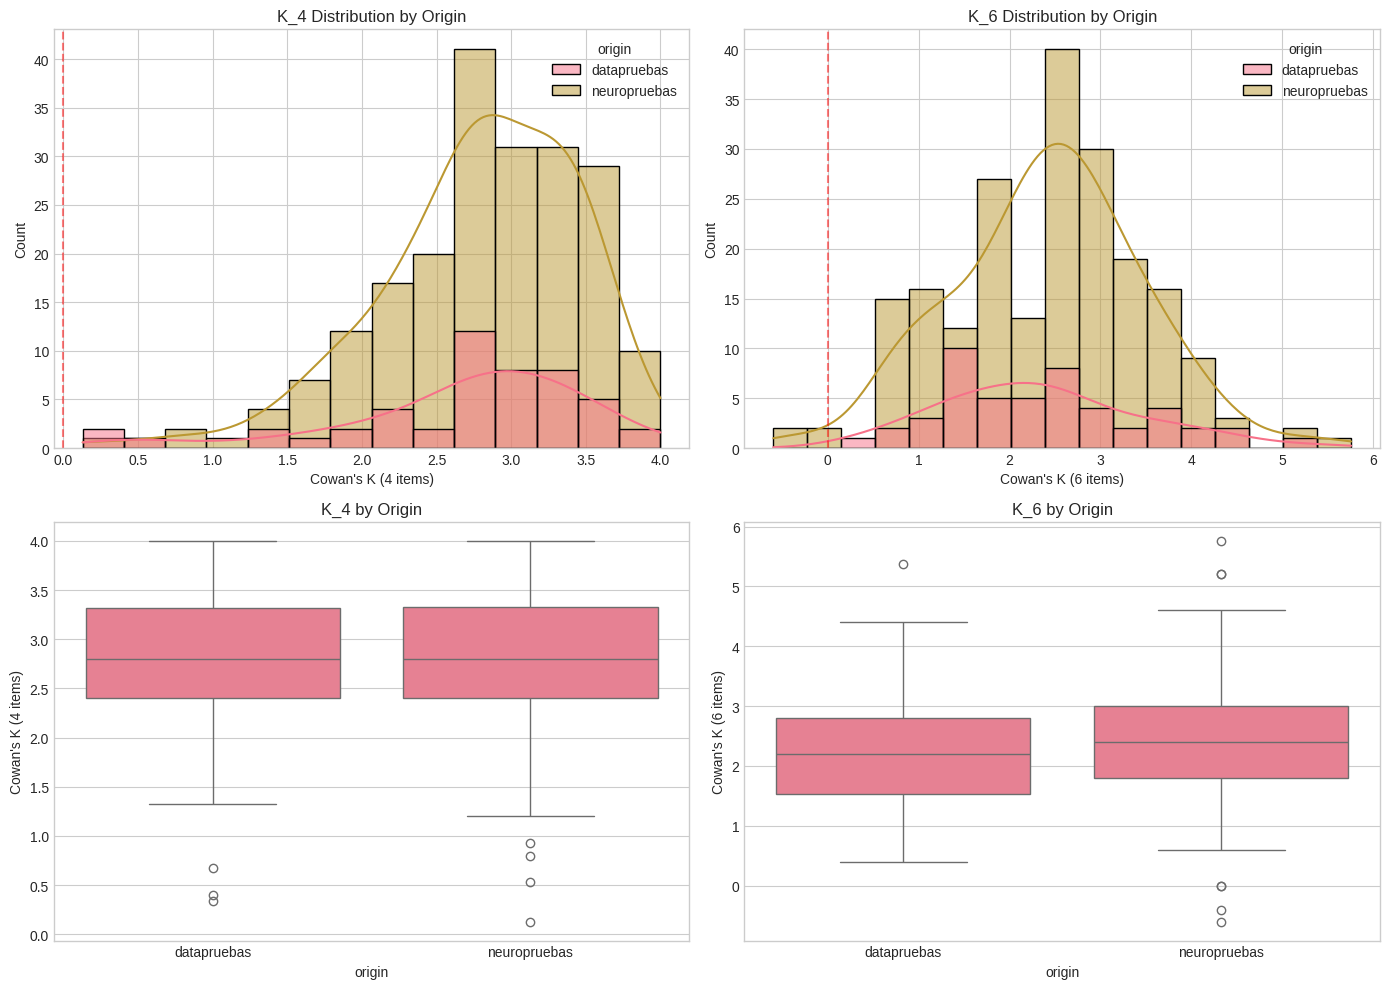

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# K_4 histogram
ax1 = axes[0, 0]
sns.histplot(data=df_cdt_all, x="K_4", hue="origin", kde=True, ax=ax1)
ax1.set_title("K_4 Distribution by Origin")
ax1.set_xlabel("Cowan's K (4 items)")
ax1.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Zero line')

# K_6 histogram
ax2 = axes[0, 1]
sns.histplot(data=df_cdt_all, x="K_6", hue="origin", kde=True, ax=ax2)
ax2.set_title("K_6 Distribution by Origin")
ax2.set_xlabel("Cowan's K (6 items)")
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Zero line')

# K_4 box plot
ax3 = axes[1, 0]
sns.boxplot(data=df_cdt_all, x="origin", y="K_4", ax=ax3)
ax3.set_title("K_4 by Origin")
ax3.set_ylabel("Cowan's K (4 items)")

# K_6 box plot
ax4 = axes[1, 1]
sns.boxplot(data=df_cdt_all, x="origin", y="K_6", ax=ax4)
ax4.set_title("K_6 by Origin")
ax4.set_ylabel("Cowan's K (6 items)")

plt.tight_layout()
plt.show()


## 5. Correlation between K_4 and K_6


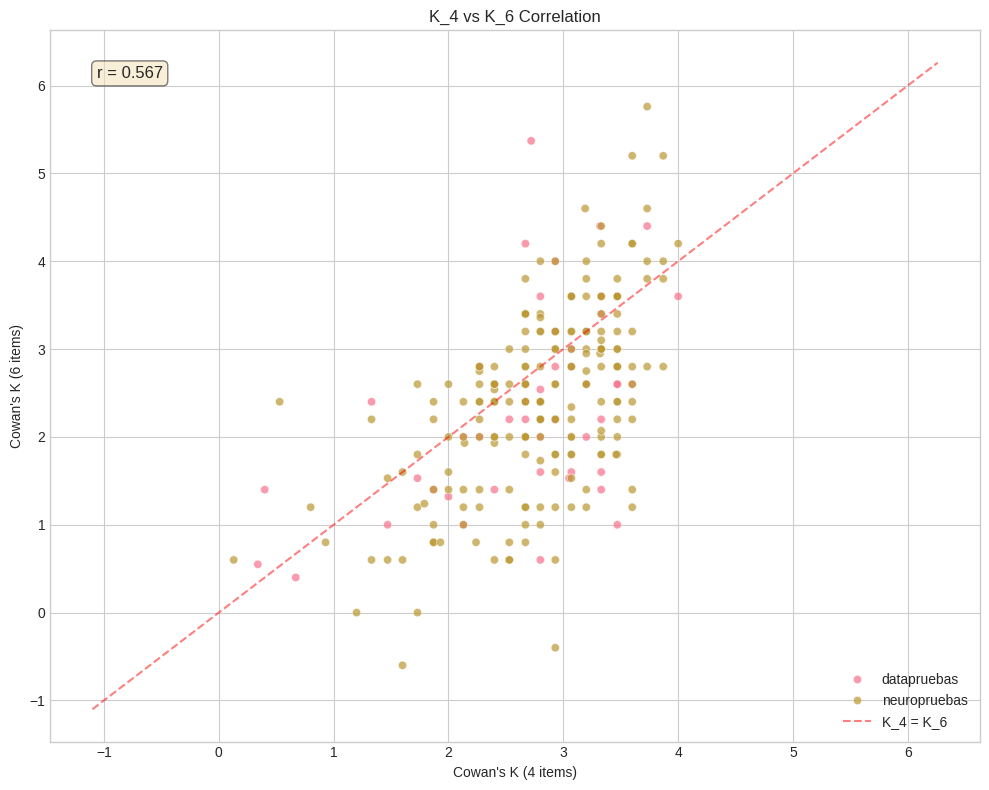

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    data=df_cdt_all,
    x="K_4",
    y="K_6",
    hue="origin",
    alpha=0.7,
    ax=ax
)

# Add diagonal line
lims = [min(df_cdt_all["K_4"].min(), df_cdt_all["K_6"].min()) - 0.5,
        max(df_cdt_all["K_4"].max(), df_cdt_all["K_6"].max()) + 0.5]
ax.plot(lims, lims, 'r--', alpha=0.5, label='K_4 = K_6')

ax.set_xlabel("Cowan's K (4 items)")
ax.set_ylabel("Cowan's K (6 items)")
ax.set_title("K_4 vs K_6 Correlation")
ax.legend()

# Calculate correlation
corr = df_cdt_all["K_4"].corr(df_cdt_all["K_6"])
ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


## 6. Quality Control Checks

Identifying potentially invalid data based on common CDT quality criteria.


In [9]:
# Check for negative K values (indicates chance-level or worse performance)
negative_k4 = df_cdt_all[df_cdt_all["K_4"] < 0]
negative_k6 = df_cdt_all[df_cdt_all["K_6"] < 0]
print(f"Subjects with negative K_4: {len(negative_k4)}")
print(f"Subjects with negative K_6: {len(negative_k6)}")


Subjects with negative K_4: 0
Subjects with negative K_6: 2


In [10]:
# Check for very low accuracy (below chance = 0.5)
low_accuracy = df_cdt_all[df_cdt_all["accuracy"] < 0.5]
print(f"Subjects with accuracy below chance (<0.5): {len(low_accuracy)}")
if len(low_accuracy) > 0:
    display(low_accuracy[["subject_id", "origin", "accuracy", "K_4", "K_6", "trials_no_contestados"]])


Subjects with accuracy below chance (<0.5): 0


In [11]:
# Check for high number of unanswered trials
high_no_response = df_cdt_all[df_cdt_all["trials_no_contestados"] > 10]
print(f"Subjects with >10 unanswered trials: {len(high_no_response)}")
if len(high_no_response) > 0:
    display(high_no_response[["subject_id", "origin", "trials_no_contestados", "accuracy", "K_4", "K_6"]].sort_values("trials_no_contestados", ascending=False))


Subjects with >10 unanswered trials: 1


,subject_id,origin,trials_no_contestados,accuracy,K_4,K_6
46,a3435232-9a62-4240-b475-8682e7a6162d,datapruebas,76,0.89,2.72,5.37


## 7. Accuracy Distribution


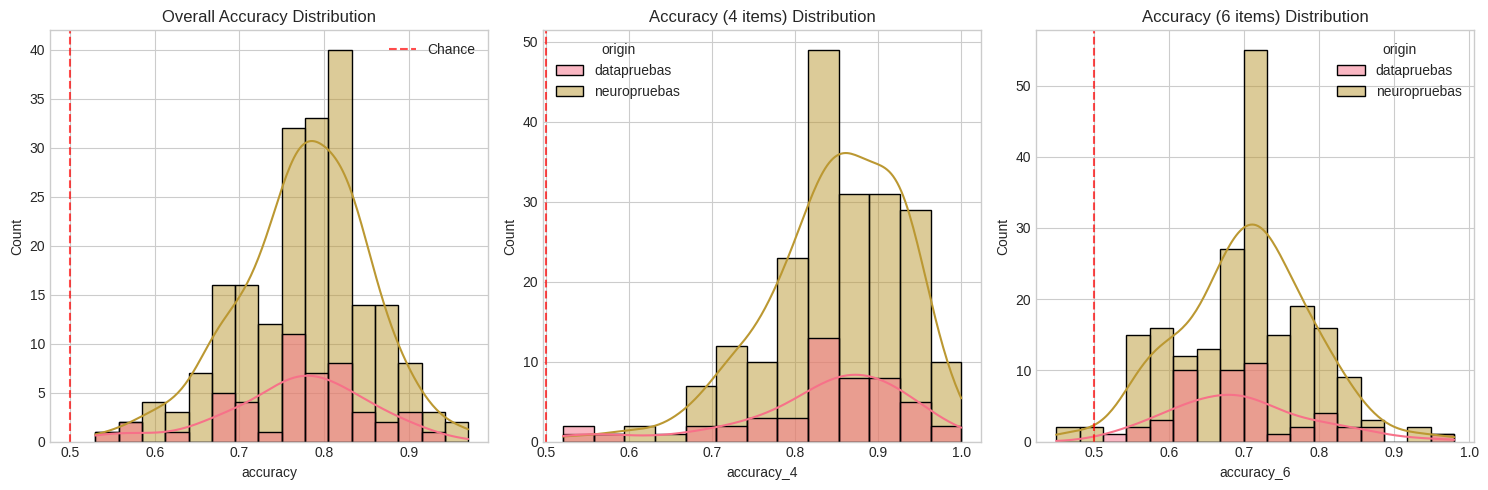

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Overall accuracy
ax1 = axes[0]
sns.histplot(data=df_cdt_all, x="accuracy", hue="origin", kde=True, ax=ax1)
ax1.set_title("Overall Accuracy Distribution")
ax1.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Chance')
ax1.legend()

# Accuracy_4
ax2 = axes[1]
if "accuracy_4" in df_cdt_all.columns:
    sns.histplot(data=df_cdt_all, x="accuracy_4", hue="origin", kde=True, ax=ax2)
    ax2.set_title("Accuracy (4 items) Distribution")
    ax2.axvline(x=0.5, color='red', linestyle='--', alpha=0.7)

# Accuracy_6
ax3 = axes[2]
if "accuracy_6" in df_cdt_all.columns:
    sns.histplot(data=df_cdt_all, x="accuracy_6", hue="origin", kde=True, ax=ax3)
    ax3.set_title("Accuracy (6 items) Distribution")
    ax3.axvline(x=0.5, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## 8. Response Time Analysis


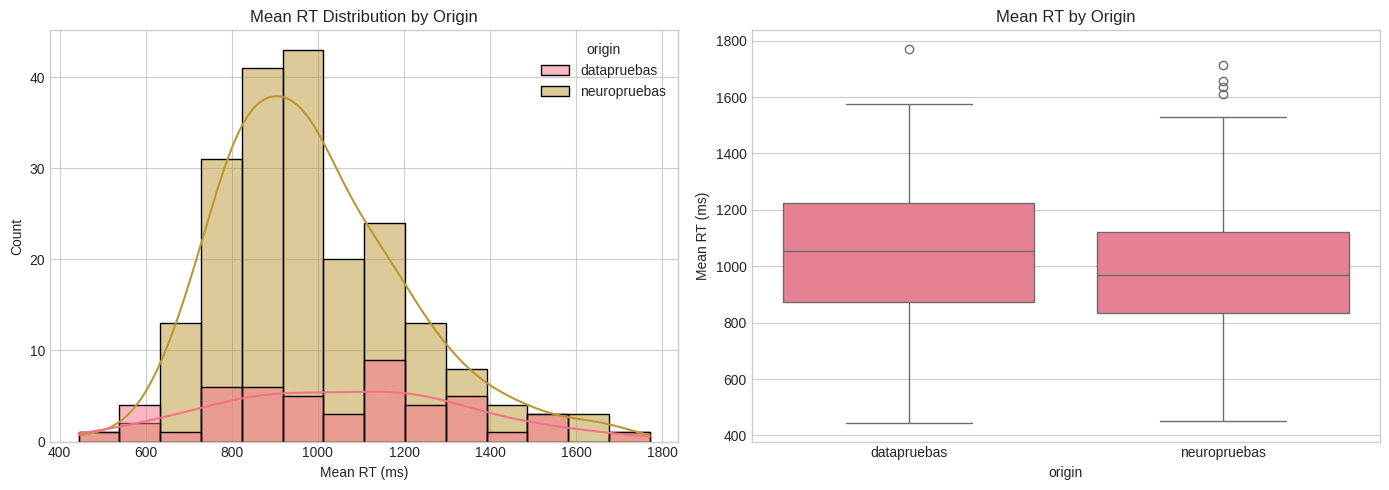

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RT histogram
ax1 = axes[0]
sns.histplot(data=df_cdt_all, x="media_rt", hue="origin", kde=True, ax=ax1)
ax1.set_title("Mean RT Distribution by Origin")
ax1.set_xlabel("Mean RT (ms)")

# RT box plot
ax2 = axes[1]
sns.boxplot(data=df_cdt_all, x="origin", y="media_rt", ax=ax2)
ax2.set_title("Mean RT by Origin")
ax2.set_ylabel("Mean RT (ms)")

plt.tight_layout()
plt.show()


## 9. Re-run and Save Results (Optional)

If you made changes to the analysis or want to create a new timestamped run:


In [14]:
# Uncomment to run fresh analysis and save results
# This will create a new timestamped folder with results

# df_cdt_all, save_path = load_cdt_analysis(save_results=True)
# print(f"Results saved to: {save_path}")

# Or run from command line:
# !python -m src.loader.cdt_analysis_loader


## 10. Summary

Key findings from CDT analysis:


In [15]:
print("CDT Analysis Summary")
print("=" * 50)
print(f"\nTotal subjects analyzed: {len(df_cdt_all)}")
print(f"  - Datapruebas: {len(df_cdt_datapruebas)}")
print(f"  - Neuropruebas: {len(df_cdt_neuropruebas)}")
print(f"\nCowan's K (Working Memory Capacity):")
print(f"  K_4: mean={df_cdt_all['K_4'].mean():.2f} (SD={df_cdt_all['K_4'].std():.2f})")
print(f"  K_6: mean={df_cdt_all['K_6'].mean():.2f} (SD={df_cdt_all['K_6'].std():.2f})")
print(f"\nMean accuracy: {df_cdt_all['accuracy'].mean():.2f}")
print(f"\nPotential quality issues:")
print(f"  - Negative K_4: {len(negative_k4)} subjects")
print(f"  - Negative K_6: {len(negative_k6)} subjects")
print(f"  - Low accuracy (<0.5): {len(low_accuracy)} subjects")
print(f"  - High no-response (>10): {len(high_no_response)} subjects")


CDT Analysis Summary

Total subjects analyzed: 256
  - Datapruebas: 49
  - Neuropruebas: 207

Cowan's K (Working Memory Capacity):
  K_4: mean=2.77 (SD=0.69)
  K_6: mean=2.40 (SD=1.06)

Mean accuracy: 0.77

Potential quality issues:
  - Negative K_4: 0 subjects
  - Negative K_6: 2 subjects
  - Low accuracy (<0.5): 0 subjects
  - High no-response (>10): 1 subjects
